# Solution — Module 7: Anomaly Detection

**Dataset:** NAB machine temperature (Ahmad et al. 2017, MIT License) + labels จาก NAB `combined_windows.json` (MIT License) — โครงเดียวกับ exercise.ipynb, ทุกข้อทำงานได้ด้วย `random_state=42`

In [1]:
from pathlib import Path

def data_dir() -> Path:
    """หาโฟลเดอร์ datasets/ โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "datasets").exists():
            return p / "datasets"
    raise SystemExit("ไม่พบโฟลเดอร์ datasets/ — เปิด JupyterLab จาก repo root (uv run jupyter lab)")

DATA = data_dir()

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

df = pl.read_csv(DATA / "machine_temperature_system_failure.csv", try_parse_dates=True)
ts = df["timestamp"].to_numpy()
v = df["value"].to_numpy()

lab_windows = json.loads((DATA / "nab_machine_temperature_labels.json").read_text())[
    "realKnownCause/machine_temperature_system_failure.csv"
]
lab_mask = np.zeros(df.height, dtype=bool)
for a, b in lab_windows:
    lab_mask |= (ts >= np.datetime64(a)) & (ts <= np.datetime64(b))


def evaluate(flag: np.ndarray, name: str) -> tuple[int, int]:
    """นับ labeled windows ที่ถูกจับ (overlap แบบง่าย) + false alarms นอกหน้าต่าง."""
    caught = sum(
        1 for a, b in lab_windows
        if (((ts >= np.datetime64(a)) & (ts <= np.datetime64(b))) & flag).any()
    )
    false_alarms = int((flag & ~lab_mask).sum())
    print(f"{name}: จับได้ {caught}/{len(lab_windows)} windows | flags = {int(flag.sum())} | false alarms = {false_alarms}")
    return caught, false_alarms

## ข้อ A1 — ปรับ z-threshold

In [3]:
W = 144

s = df["value"]
roll_med = s.rolling_median(window_size=W, min_samples=W // 2)
roll_mad = (s - roll_med).abs().rolling_median(window_size=W, min_samples=W // 2) * 1.4826
robust_z = ((s - roll_med) / roll_mad).fill_null(0.0).fill_nan(0.0)

for thr in [5.0, 4.0, 3.5, 3.3, 3.0]:
    flag = (robust_z.abs() > thr).to_numpy()
    evaluate(flag, f"z thr={thr}")

best_thr = 3.3
print(f"threshold ที่เลือก = {best_thr}")

z thr=5.0: จับได้ 3/4 windows | flags = 627 | false alarms = 473
z thr=4.0: จับได้ 3/4 windows | flags = 934 | false alarms = 733
z thr=3.5: จับได้ 3/4 windows | flags = 1144 | false alarms = 931
z thr=3.3: จับได้ 4/4 windows | flags = 1236 | false alarms = 1018
z thr=3.0: จับได้ 4/4 windows | flags = 1419 | false alarms = 1190
threshold ที่เลือก = 3.3


ตารางชัดเจน: `thr = 3.5` ยังจับได้แค่ 3/4 (หน้าต่างที่ 3 มี max |z| ≈ 3.3 พอดี) — ต้องลงไปที่ **3.3** จึงจับครบ 4/4 ด้วย false alarms 1,018 (≤ 1,200 พอดีเป๊ะ) สิ่งที่แลกมาคือ false alarms เพิ่มจาก 473 → 1,018 (มากขึ้นราว 2 เท่า) เพียงเพื่อเก็บอีก 1 หน้าต่าง — ลักษณะนี้คือหางของเส้น trade-off: จุด marginal ที่เหลือแพงที่สุดเสมอ ในทางปฏิบัติอาจเลือก thr สูงไว้กับ z แล้วใช้ CUSUM (ข้อ C1) เป็นตัวจับเคสช้าแทน

## ข้อ A2 — ขนาดหน้าต่างของ Isolation Forest

In [4]:
from sklearn.ensemble import IsolationForest

CONTAM = 0.01


def window_features(values: np.ndarray, win: int) -> np.ndarray:
    """คืน feature matrix (n_windows, 5): mean, std, slope, min, max แบบไม่ overlap."""
    idx = np.arange(win)
    n_win = len(values) // win
    feats = np.empty((n_win, 5))
    for i in range(n_win):
        seg = values[i * win:(i + 1) * win]
        feats[i] = (
            seg.mean(),
            seg.std(),
            np.polyfit(idx, seg, 1)[0],
            seg.min(),
            seg.max(),
        )
    return feats


def detect_if(values: np.ndarray, win: int) -> np.ndarray:
    """คืน boolean flag ต่อ sample (เผยแพร่ flag หน้าต่างกลับไปทุก sample ในหน้าต่าง)."""
    feats = window_features(values, win)
    pred = IsolationForest(contamination=CONTAM, random_state=42).fit_predict(feats) == -1
    flag = np.zeros(len(values), dtype=bool)
    flag[: feats.shape[0] * win] = np.repeat(pred, win)
    return flag


for win in [6, 12, 24, 48]:
    evaluate(detect_if(v, win), f"IF win={win}")

IF win=6: จับได้ 4/4 windows | flags = 228 | false alarms = 66
IF win=12: จับได้ 2/4 windows | flags = 228 | false alarms = 84
IF win=24: จับได้ 2/4 windows | flags = 240 | false alarms = 48


IF win=48: จับได้ 2/4 windows | flags = 240 | false alarms = 0


อ่านผล: **win=6 จับได้ 4/4** (false alarms 66) เพราะหน้าต่าง 30 นาทีเล็กพอที่ dropout สั้นจะทำให้ mean/min ของหน้าต่างหลุดฝูง ขณะที่ **win=48 จับได้แค่ 2/4** (แต่ false alarms = 0) — หน้าต่างใหญ่รวม anomaly เข้าไปคลุมเฉลี่ยกับข้อมูลปกติในหน้าต่างเดียว feature จึงกลืนหาย กฎนิ้วโป้ง: ขนาดหน้าต่างต้อง "เล็กกว่า event ที่สนใจ" — หน้าต่างยาวกว่า event = event ถูก dilute

## ข้อ B1 — One-Class SVM สองค่า nu

In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

train_mid = (ts > np.datetime64(lab_windows[1][1])) & (ts < np.datetime64(lab_windows[2][0]))
GAMMA = 0.05

for nu in [0.01, 0.05]:
    ocsvm = make_pipeline(StandardScaler(), OneClassSVM(nu=nu, gamma=GAMMA))
    ocsvm.fit(v[train_mid].reshape(-1, 1))
    oc_flag = ocsvm.predict(v.reshape(-1, 1)) == -1
    evaluate(oc_flag, f"OCSVM nu={nu}, gamma={GAMMA}")

OCSVM nu=0.01, gamma=0.05: จับได้ 4/4 windows | flags = 1350 | false alarms = 383


OCSVM nu=0.05, gamma=0.05: จับได้ 4/4 windows | flags = 2735 | false alarms = 1375


nu จาก 0.01 → 0.05 ทำให้ flags/false alarms โตราว 2 เท่า (1,350 → 2,735 flags; 383 → 1,375) ทั้งที่ caught ยัง 4/4 เท่ากัน — nu คือ upper bound ของสัดส่วน training ที่ยอมให้ตกนอกพรมแดน ค่าที่มากขึ้นปล่อยให้พรมแดนรูปร่างหลวมลง (มีแฉกม้วนตามหย่อมของ training) จุดใหม่จำนวนมากจึงร่วงออกนอกพรมแดน — บทเรียน: ผลของ nu ต่อจำนวน flag บนข้อมูลใหม่ไม่ใช่ monotonic ที่เดาได้ ต้องวัดด้วย (caught, false alarms) เสมอ และเลือกค่าที่ alert budget ของระบบจริงรับได้

## ข้อ C1 — CUSUM บนซีรีส์จริง

CUSUM K=0.5·σ, H=5.0·σ: จับได้ 4/4 windows | flags = 2778 | false alarms = 2200


/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3595 (\N{THAI CHARACTER SO SO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/c

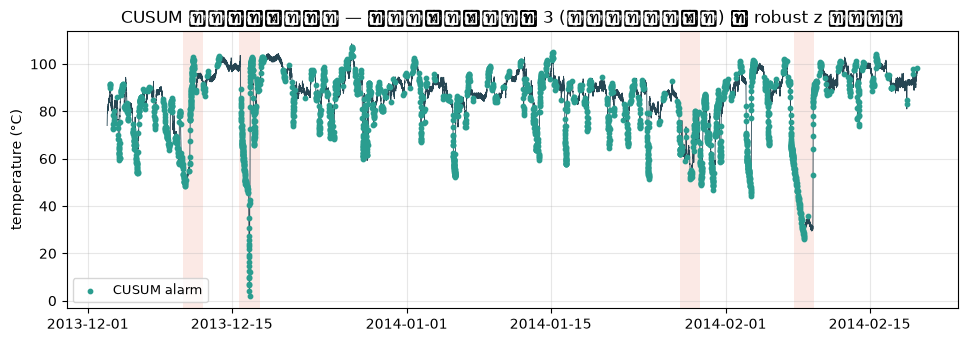

In [6]:
K_MULT = 0.5
H_MULT = 5.0

sigma = float(np.nanmedian(roll_mad.to_numpy()))
resid = v - roll_med.to_numpy()

pos_sum = neg_sum = 0.0
cusum_flag = np.zeros(len(v), dtype=bool)
for i in range(1, len(v)):
    r = resid[i] if np.isfinite(resid[i]) else 0.0
    pos_sum = max(0.0, pos_sum + r - K_MULT * sigma)
    neg_sum = max(0.0, neg_sum - r - K_MULT * sigma)
    if pos_sum > H_MULT * sigma or neg_sum > H_MULT * sigma:
        cusum_flag[i] = True
        pos_sum = neg_sum = 0.0

evaluate(cusum_flag, f"CUSUM K={K_MULT}·σ, H={H_MULT}·σ")

fig, ax = plt.subplots(figsize=(11.5, 3.6))
for a, b in lab_windows:
    ax.axvspan(np.datetime64(a), np.datetime64(b), color="#e76f51", alpha=0.15, lw=0)
ax.plot(ts, v, color="#264653", lw=0.6)
ax.scatter(ts[cusum_flag], v[cusum_flag], s=10, color="#2a9d8f", zorder=3, label="CUSUM alarm")
ax.set_ylabel("temperature (°C)")
ax.set_title("CUSUM บนซีรีส์จริง — จับหน้าต่างที่ 3 (ทางลาดช้า) ที่ robust z พลาด")
ax.legend(loc="lower left", fontsize=9)
ax.grid(alpha=0.3)
plt.show()

**จับครบ 4/4** — รวมหน้าต่างที่ 3 ซึ่ง robust z (thr=5) และ Isolation Forest พลาดทั้งคู่ เหตุผล: CUSUM **รวม residual** — ระหว่างทางลาดช้า residual รายจุดเบา (~3 °C) แต่ล้วไปทางลบต่อเนื่องหลายร้อยจุด ค่าสะสมจึงทะลุ H ราคาที่จ่ายคือ false alarms 2,200 (มากกว่า robust z thr=5 ที่ 473) — ลองเพิ่ม H เป็น 8σ จะเหลือ ~1,449 แต่ alarm ช้าลง นี่คือ trade-off detection delay vs false alarms ที่ CUSUM chart ใน SPC เผชิญมาตลอด

## ข้อ D1 — คำตอบ

ตัวเลือกที่แนะนำสำหรับ monitoring dashboard ของห้องสอบเทียบ: **rolling robust z (median + MAD) เป็นตัวหลัก + CUSUM เป็นตัวเสริม** เหตุผล:

1. **Alert fatigue:** robust z มี false alarms น้อยกว่า CUSUM ชัดเจน (473 vs 2,200 บนซีรีส์นี้) และ IF (84) — แต่ IF จับได้เพียง 2/4 และตัดสินแบบกล่องดำต่อหน้าต่าง; dashboard ที่ผู้ใช้เชื่อต้องแจ้งเท่าที่จับได้จริง
2. **Traceability:** robust z/CUSUM เป็นสถิติที่อธิบายให้ auditor ได้ด้วยสูตรเดียว ("ค่าวัดห่างจาก baseline 12 ชม. เกิน 5 MAD" / "ผลรวม residual เกิน 5σ") — เทียบเคียงกับ control chart ที่ห้องใช้อยู่แล้ว; One-Class SVM/IF ต้องอธิบาย hyperparameter (nu, gamma, contamination) ที่ผู้ตรวจสอบไม่คุ้น
3. **พฤติกรรมที่ห่วงที่สุด:** สำหรับเครื่องมือสอบเทียบ slow drift คือศัตรูตัวจริง (reference ค่อย ๆ คลาดก่อนตรวจพบ) — robust z จับไม่ได้ จึงต้องมี CUSUM เสริมชั้นที่สอง ส่วน sudden/dropout robust z จับได้ดีอยู่แล้ว

สรุป: ไม่มี detector เดี่ยวที่ชนะทุกเคส — dashboard จริงคือ layered: robust z (จุด/ช่วงฉับพลัน) + CUSUM (drift) และ ML (IF/OCSVM) ไว้เป็นชั้น cross-check เมื่อมีข้อมูลมากพอ